In [1]:
import numpy as np
import pandas as pd

#reading data
df=pd.read_csv(r"C:\Users\Vijay\Data Analytics\food_ordering_behavior_dataset.csv")
print(df.shape)
print(df.columns)

(50000, 19)
Index(['order_id', 'user_id', 'age', 'city', 'order_time', 'day_type',
       'cuisine', 'meal_type', 'restaurant_type', 'order_value',
       'discount_applied', 'delivery_fee', 'time_taken_to_order',
       'rating_given', 'is_repeat_order', 'mood', 'hunger_level', 'company',
       'rainy_weather'],
      dtype='object')


In [2]:
#total null values
print("total null values\n")
print(df.isnull().sum())
#total no null values
print("total no null values\n")
print(df.count())
#top 10 rows
print("top 10 rows\n")
print(df.head(10))
#bottom 10 rows
print("bottom 10 rows\n")
print(df.tail(10))

total null values

order_id               0
user_id                0
age                    0
city                   0
order_time             0
day_type               0
cuisine                0
meal_type              0
restaurant_type        0
order_value            0
discount_applied       0
delivery_fee           0
time_taken_to_order    0
rating_given           0
is_repeat_order        0
mood                   0
hunger_level           0
company                0
rainy_weather          0
dtype: int64
total no null values

order_id               50000
user_id                50000
age                    50000
city                   50000
order_time             50000
day_type               50000
cuisine                50000
meal_type              50000
restaurant_type        50000
order_value            50000
discount_applied       50000
delivery_fee           50000
time_taken_to_order    50000
rating_given           50000
is_repeat_order        50000
mood                   50000
hunger_

In [3]:
#Converting order_time  into ordered category
df["order_time"] = pd.Categorical(
    df["order_time"],
    categories=["Morning", "Afternoon", "Evening", "Night"],
    ordered=True
)

In [4]:
time_map = {
    "Morning": 9,
    "Afternoon": 14,
    "Evening": 19,
    "Night": 23
}

df["approx_hour"] = df["order_time"].map(time_map)

In [5]:
#Peak Ordering Time
df["order_time"].value_counts()

order_time
Evening      12550
Morning      12524
Night        12513
Afternoon    12413
Name: count, dtype: int64

In [6]:
#Revenue by Time
df.groupby("order_time")["order_value"].mean()

C:\Users\Vijay\AppData\Local\Temp\ipykernel_14416\1156316001.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("order_time")["order_value"].mean()


order_time
Morning      545.768524
Afternoon    549.129219
Evening      550.132112
Night        545.900344
Name: order_value, dtype: float64

In [7]:
#Time vs Mood
df.groupby(["order_time", "mood"]).size().unstack()

C:\Users\Vijay\AppData\Local\Temp\ipykernel_14416\4201449372.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["order_time", "mood"]).size().unstack()


mood,Celebrating,Happy,Lazy,Stressed
order_time,,,,
Morning,3148,3076,3066,3234
Afternoon,3122,3127,3050,3114
Evening,3145,3162,3029,3214
Night,3165,3100,3138,3110


In [8]:
#Time vs Meal
df.groupby(["order_time", "meal_type"], observed=True).size().unstack()

meal_type,Breakfast,Dinner,Lunch,Snacks
order_time,,,,
Morning,3162,3074,3179,3109
Afternoon,3089,3080,3097,3147
Evening,3141,3124,3139,3146
Night,3186,3111,3097,3119


In [9]:
#Time vs Repeat
df.groupby("order_time", observed=True)["is_repeat_order"].value_counts(normalize=True)

order_time  is_repeat_order
Morning     No                 0.505270
            Yes                0.494730
Afternoon   No                 0.500040
            Yes                0.499960
Evening     Yes                0.501434
            No                 0.498566
Night       Yes                0.502757
            No                 0.497243
Name: proportion, dtype: float64

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<h3>Orders Distribution by Time of Day</h3>

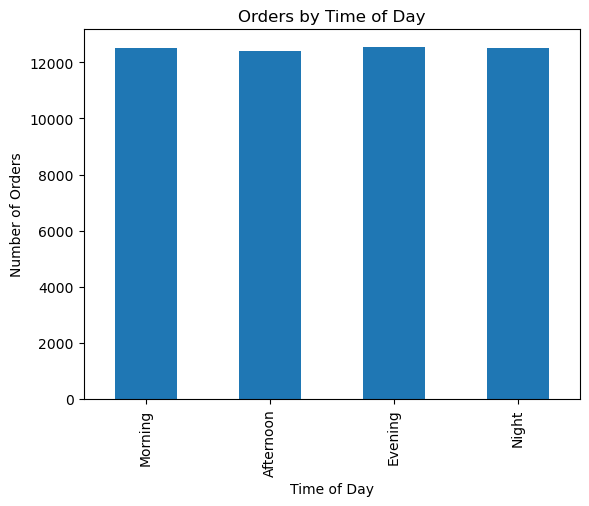

In [11]:
df["order_time"].value_counts().sort_index().plot(kind="bar")

plt.title("Orders by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Orders")
plt.show()

<h3>Average Order Value by Time</h3>

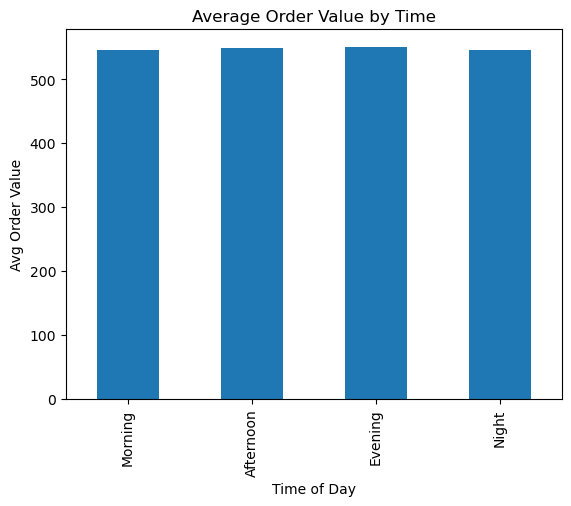

In [29]:
df.groupby("order_time",observed=True)["order_value"].mean().plot(kind="bar")

plt.title("Average Order Value by Time")
plt.xlabel("Time of Day")
plt.ylabel("Avg Order Value")
plt.show()

<h3>Cuisine Popularity</h3>

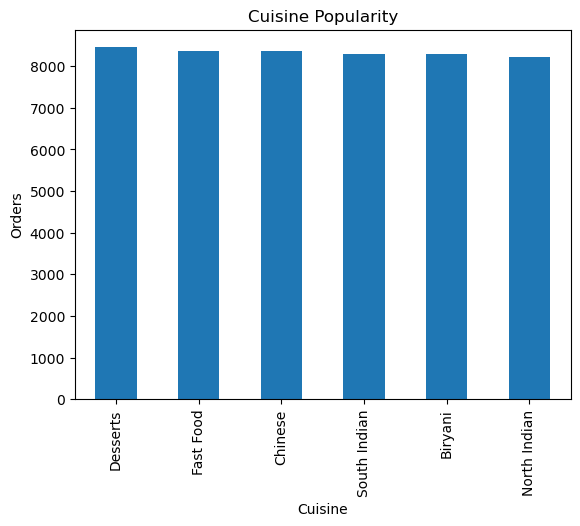

In [13]:
df["cuisine"].value_counts().plot(kind="bar")

plt.title("Cuisine Popularity")
plt.xlabel("Cuisine")
plt.ylabel("Orders")
plt.show()

<h3>Weekend vs Weekday Orders</h3>

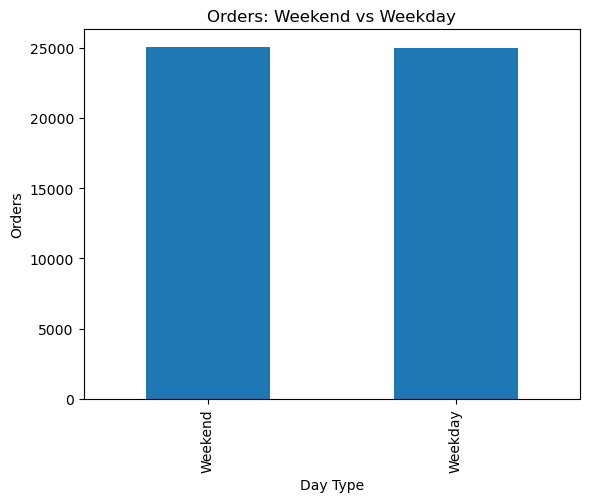

In [14]:
df["day_type"].value_counts().plot(kind="bar")

plt.title("Orders: Weekend vs Weekday")
plt.xlabel("Day Type")
plt.ylabel("Orders")
plt.show()

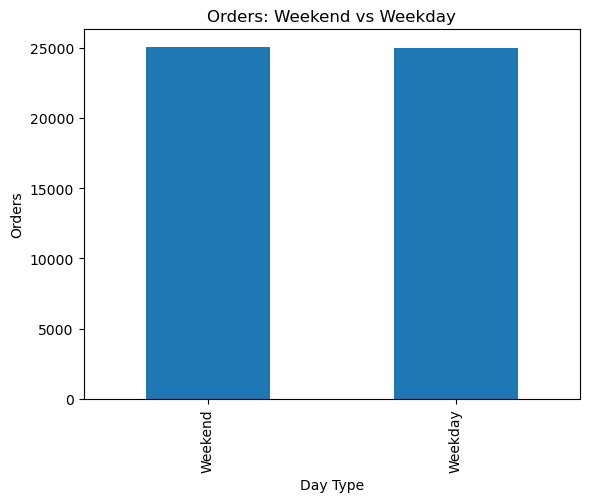

In [15]:
df["day_type"].value_counts().plot(kind="bar")

plt.title("Orders: Weekend vs Weekday")
plt.xlabel("Day Type")
plt.ylabel("Orders")
plt.show()

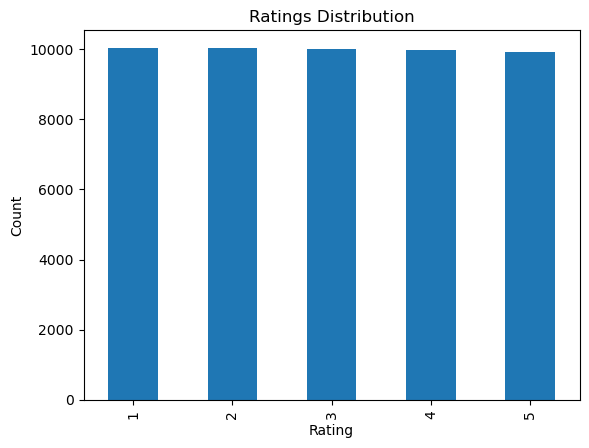

In [16]:
df["rating_given"].value_counts().sort_index().plot(kind="bar")

plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

<h3>Rain Impact on Orders</h3>

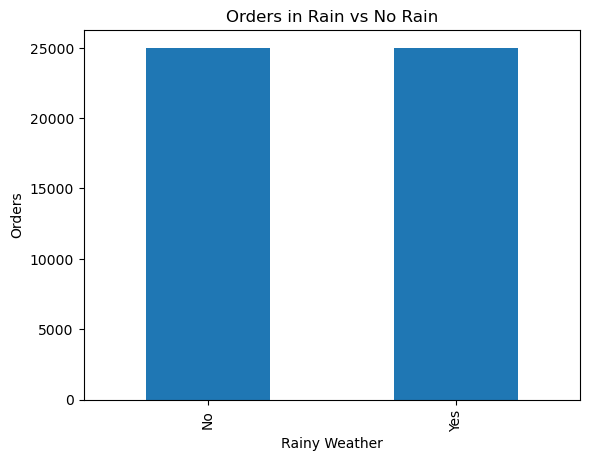

In [17]:
df["rainy_weather"].value_counts().plot(kind="bar")

plt.title("Orders in Rain vs No Rain")
plt.xlabel("Rainy Weather")
plt.ylabel("Orders")
plt.show()

<h3>Order Distribution by Time of Day</h3>

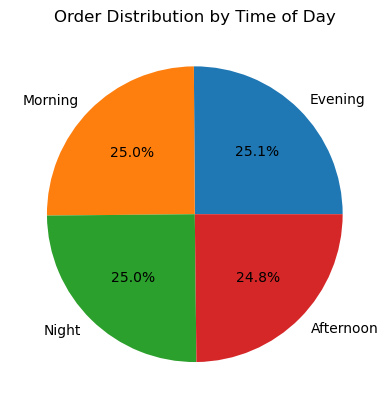

In [18]:
df["order_time"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Order Distribution by Time of Day")
plt.ylabel("")
plt.show()

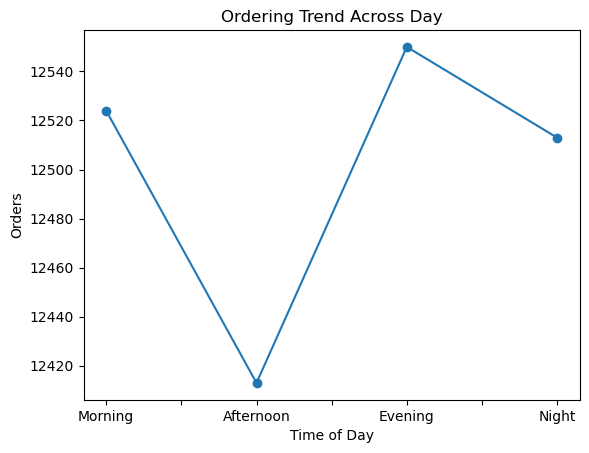

In [19]:
df["order_time"].value_counts().sort_index().plot(kind="line", marker="o")

plt.title("Ordering Trend Across Day")
plt.xlabel("Time of Day")
plt.ylabel("Orders")
plt.show()

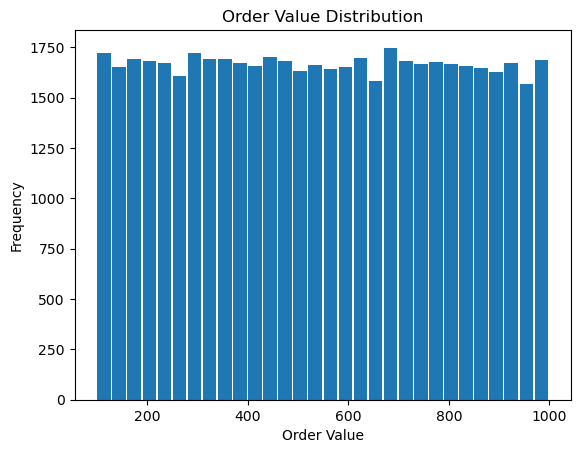

In [20]:
df["order_value"].plot(kind="hist", bins=30, rwidth=0.9)

plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

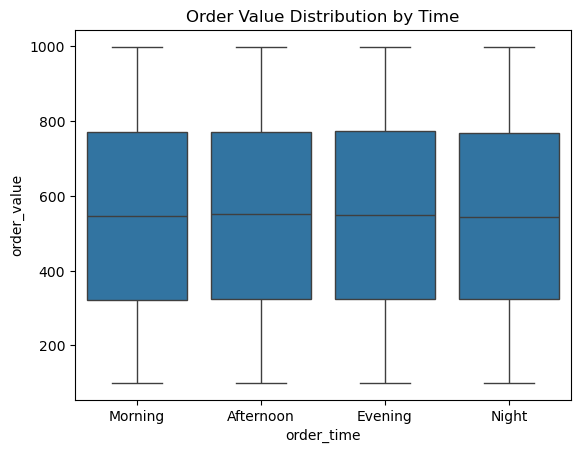

In [21]:
import seaborn as sns

sns.boxplot(x="order_time", y="order_value", data=df)

plt.title("Order Value Distribution by Time")
plt.show()

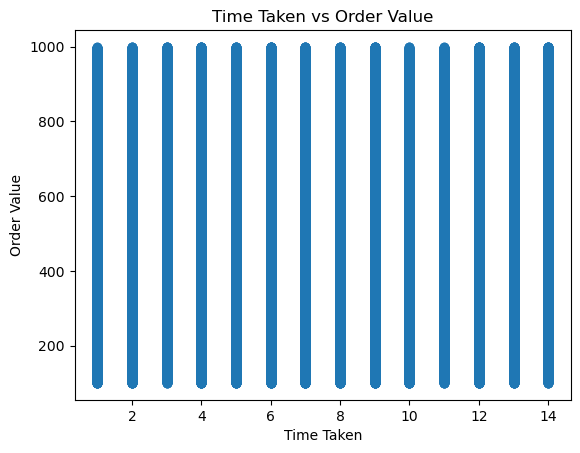

In [22]:
plt.scatter(df["time_taken_to_order"], df["order_value"])

plt.title("Time Taken vs Order Value")
plt.xlabel("Time Taken")
plt.ylabel("Order Value")
plt.show()

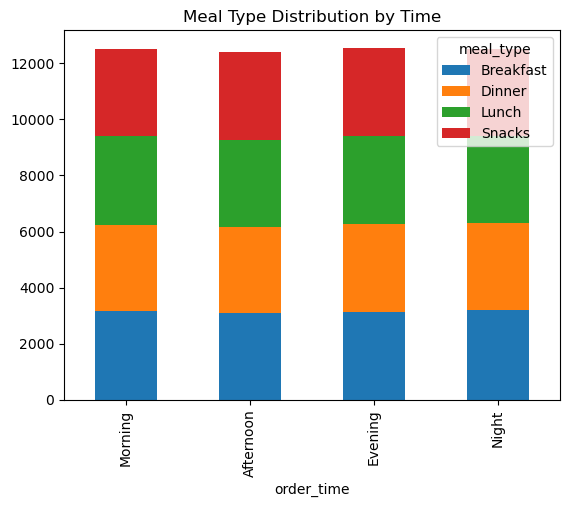

In [23]:
pivot = pd.crosstab(df["order_time"], df["meal_type"])

pivot.plot(kind="bar", stacked=True)

plt.title("Meal Type Distribution by Time")
plt.show()

C:\Users\Vijay\AppData\Local\Temp\ipykernel_14416\2944769402.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


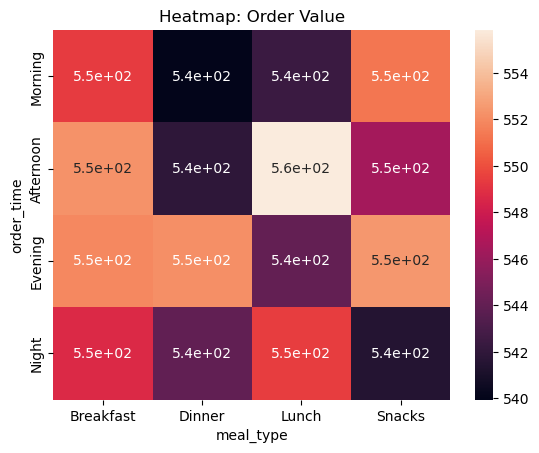

In [24]:
pivot = df.pivot_table(
    values="order_value",
    index="order_time",
    columns="meal_type",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True)

plt.title("Heatmap: Order Value")
plt.show()

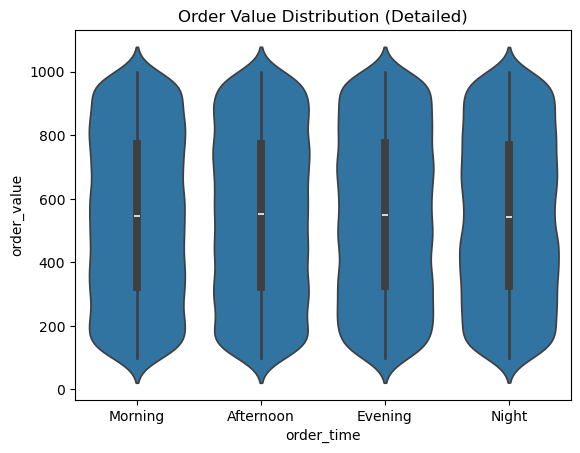

In [25]:
sns.violinplot(x="order_time", y="order_value", data=df)

plt.title("Order Value Distribution (Detailed)")
plt.show()

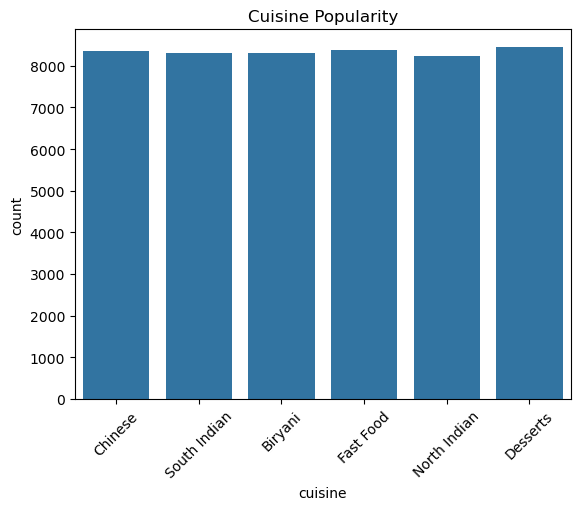

In [26]:
sns.countplot(x="cuisine", data=df)

plt.xticks(rotation=45)
plt.title("Cuisine Popularity")
plt.show()

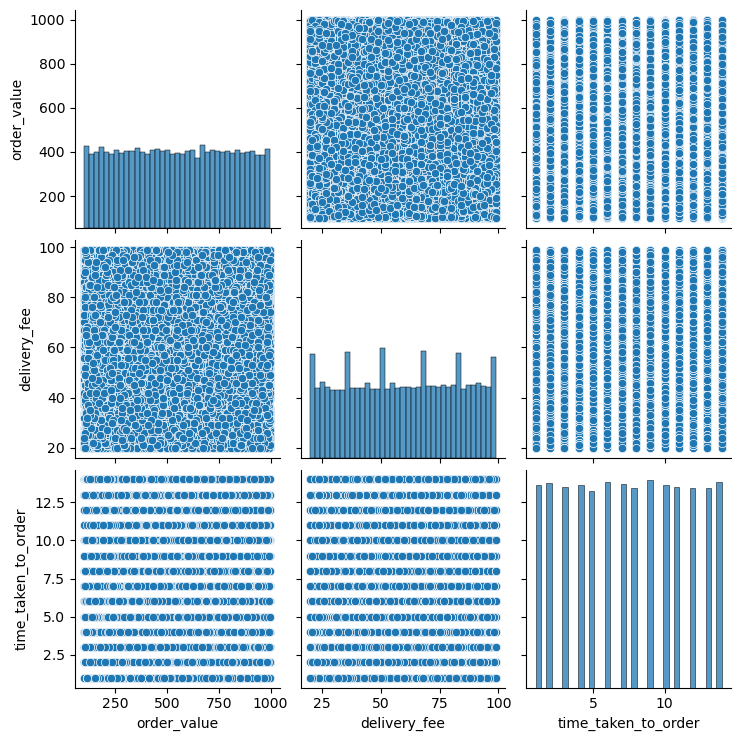

In [27]:
sns.pairplot(df[["order_value", "delivery_fee", "time_taken_to_order"]])

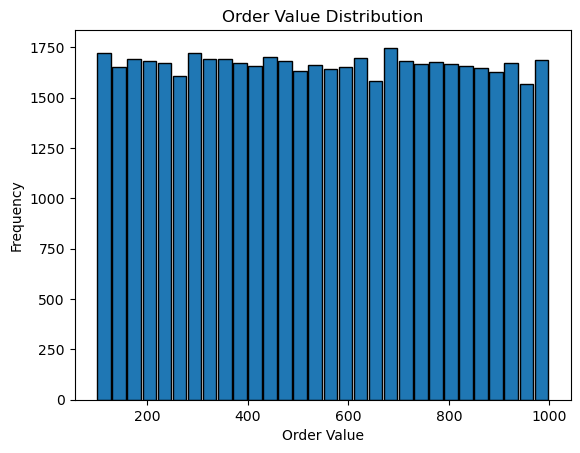

In [28]:
plt.hist(df["order_value"], bins=30, rwidth=0.9, edgecolor="black")

plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()